# Neuron-Surgery Observing and boosting SQL-Activations in LLMs

In [1]:
import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModelForCausalLM
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. CONFIG
DATA_PATH = "sql-nonsql.csv"
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"
DEVICE     = "mps"
N_SAMPLES  = 1000
MAX_LEN    = 128
BATCH_SIZE = 16
AE_H1      = 1024
AE_LATENT  = 256
L1_LAMBDA  = 1e-3
AE_LR      = 1e-4
AE_EPOCHS  = 50
TOP_K_LAT  = 10
TOP_N_NEUR = 50
BIAS_ALPHA = 0.5

# 2. LOAD & SAMPLE
df = pd.read_csv(DATA_PATH)
df_sql   = df[df.label=="sql"].sample(N_SAMPLES, random_state=0)
df_nonsql= df[df.label=="non-sql"].sample(N_SAMPLES, random_state=0)
df_all   = pd.concat([df_sql, df_nonsql]).reset_index(drop=True)
texts    = df_all.text.tolist()
labels   = np.array([1 if l=="sql" else 0 for l in df_all.label])


# 3. TOKENIZER & MODEL
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token_id = tokenizer.eos_token_id
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    load_in_8bit=False,
    torch_dtype=torch.float16,
    device_map="mps",
    output_hidden_states=True
)
model.eval()


# 4. EXTRACT FINAL‐TOKEN ACTIVATIONS
def get_last_hidden_states(batch_input_ids, batch_attn_mask):
    # forward will now populate .hidden_states
    outputs = model(
        input_ids=batch_input_ids,
        attention_mask=batch_attn_mask,
        # you can also pass these here if you didn't set them in config:
        output_hidden_states=True, return_dict=True
    )
    # hidden_states is a tuple: (embeddings, layer1, …, layer36)
    last_hs = outputs.hidden_states[-1]   # shape (B, L, H)
    return last_hs
acts = []
labs = []
dset = tokenizer(texts, padding="longest", truncation=True,
                 max_length=MAX_LEN, return_tensors="pt")
ds = TensorDataset(dset["input_ids"], dset["attention_mask"], torch.from_numpy(labels))
loader = DataLoader(ds, batch_size=BATCH_SIZE)


/Users/thore/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/thore/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/thore/Library/Python/3.9/lib/python/site-packages/transformers/generation/configuration_utils.py:818: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_hidden_states` is. When `return_dict_in_generate` is not `True`, `output_hidden_states` is ignored.
  warnings.warn(
Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.
Loading checkpoint shards: 100%|██████████| 2/2 [00:07<00:00

Extracting: 100%|██████████| 125/125 [02:46<00:00,  1.33s/it]


step 4 finished
AE Epoch 1/50, loss=7.9604e+00
AE Epoch 2/50, loss=2.6415e+00
AE Epoch 3/50, loss=1.6647e+00
AE Epoch 4/50, loss=1.3282e+00
AE Epoch 5/50, loss=1.0705e+00
AE Epoch 6/50, loss=8.7373e-01
AE Epoch 7/50, loss=6.9846e-01
AE Epoch 8/50, loss=5.5585e-01
AE Epoch 9/50, loss=4.4350e-01
AE Epoch 10/50, loss=3.5841e-01
AE Epoch 11/50, loss=2.9632e-01
AE Epoch 12/50, loss=2.4709e-01
AE Epoch 13/50, loss=2.1085e-01
AE Epoch 14/50, loss=1.8538e-01
AE Epoch 15/50, loss=1.6861e-01
AE Epoch 16/50, loss=1.5526e-01
AE Epoch 17/50, loss=1.4633e-01
AE Epoch 18/50, loss=1.4018e-01
AE Epoch 19/50, loss=1.3438e-01
AE Epoch 20/50, loss=1.3013e-01
AE Epoch 21/50, loss=1.2529e-01
AE Epoch 22/50, loss=1.2263e-01
AE Epoch 23/50, loss=1.1821e-01
AE Epoch 24/50, loss=1.1544e-01
AE Epoch 25/50, loss=1.1265e-01
AE Epoch 26/50, loss=1.0965e-01
AE Epoch 27/50, loss=1.0734e-01
AE Epoch 28/50, loss=1.0504e-01
AE Epoch 29/50, loss=1.0247e-01
AE Epoch 30/50, loss=1.0052e-01
AE Epoch 31/50, loss=9.8552e-02
A

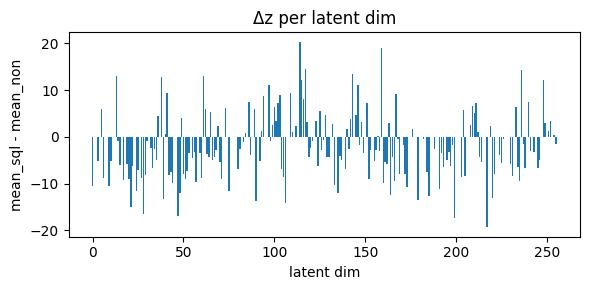

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


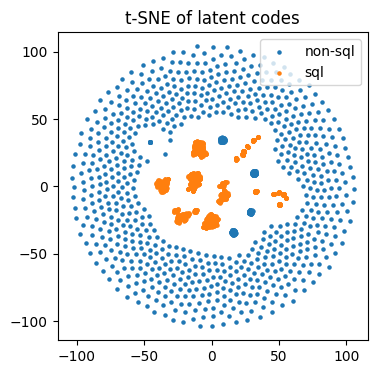

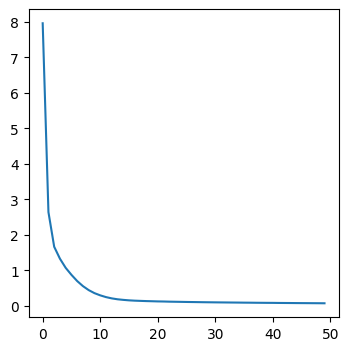

In [2]:

with torch.no_grad():
    for input_ids, attention_mask, lbl in tqdm(loader, desc="Extracting"):
        input_ids = input_ids.to(DEVICE)
        out = model(input_ids=input_ids, output_hidden_states=True)
        #hs = out.last_hidden_state     # logits instead of hidden_states

        #hs = out.hidden_states[layer_indices[0]]
    

        hs = get_last_hidden_states(input_ids, attention_mask)
        # now pick off the activations at the final non‐pad token:
        lengths = attention_mask.sum(dim=1) - 1   # (B,)
        #batch_acts = hs[torch.arange(len(texts), device=DEVICE), lengths]
        

        
        batch_acts = hs[torch.arange(hs.size(0), device=DEVICE), lengths]  # (B, H)
        acts.append(batch_acts.cpu())
        labs.append(lbl)
print("step 4 finished")
acts = torch.cat(acts, dim=0)    # (2000, H)
labs = torch.cat(labs, dim=0)    # (2000,)


# 5. SPARSE AUTOENCODER
class SparseAE(nn.Module):
    def __init__(self, D, H1, Z):
        super().__init__()
        self.fc1 = nn.Linear(D, H1)
        self.fc2 = nn.Linear(H1, Z)
        self.fc3 = nn.Linear(Z, H1)
        self.fc4 = nn.Linear(H1, D)
        self.act = nn.ReLU()

    def encode(self, x):
        return self.act(self.fc2(self.act(self.fc1(x))))

    def decode(self, z):
        return self.fc4(self.act(self.fc3(z)))

    def forward(self, x):
        z = self.encode(x)
        xr= self.decode(z)
        return xr, z

# prepare DataLoader
ae_ds = TensorDataset(acts, acts)
ae_loader = DataLoader(ae_ds, batch_size=64, shuffle=True)

ae = SparseAE(D=acts.size(1), H1=AE_H1, Z=AE_LATENT).to(DEVICE)
opt = torch.optim.AdamW(ae.parameters(), lr=AE_LR)
mse = nn.MSELoss()

losses_log = []
for epoch in range(AE_EPOCHS):
    tot=0
    for x,_ in ae_loader:
        x = x.float().to(DEVICE)
        xr,z = ae(x)
        loss = mse(xr, x) + L1_LAMBDA * z.abs().mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
        tot += loss.item()*x.size(0)
    loss = tot/len(ae_ds)
    losses_log.append(loss)
    print(f"AE Epoch {epoch+1}/{AE_EPOCHS}, loss={(loss):.4e}")


# 6. IDENTIFY SQL‐SELECTIVE NEURONS
with torch.no_grad():
    Z = ae.encode(acts.float().to(DEVICE)).cpu().numpy()    # (2000, Z)
z_sql     = Z[labs.numpy()==1]
z_nonsql  = Z[labs.numpy()==0]
dz        = z_sql.mean(0) - z_nonsql.mean(0)     # (Z,)
topk_idx  = np.argsort(np.abs(dz))[-TOP_K_LAT:]

# effective weight matrix W_eff = W2 @ W1
W1 = ae.fc1.weight.data.clone()      # (H1, D)
W2 = ae.fc2.weight.data.clone()      # (Z, H1)
W_eff = W2 @ W1                      # (Z, D)

# score each neuron i:
#   score[i] = sum_j |dz[j]| * |W_eff[j,i]|  over top‐k latent dims
scores = (np.abs(dz[topk_idx])[:,None] * W_eff[topk_idx].abs().cpu().numpy()).sum(0)
topn_neurons = np.argsort(scores)[-TOP_N_NEUR:]


# 7. VISUALIZATION (example: Δz bar + t-SNE)
plt.figure(figsize=(6,3))
plt.bar(np.arange(len(dz)), dz)
plt.title("Δz per latent dim"); plt.xlabel("latent dim"); plt.ylabel("mean_sql - mean_non")
plt.tight_layout(); plt.show()

tsne = TSNE(2, init="random", random_state=0)
Z2 = tsne.fit_transform(Z)
plt.figure(figsize=(4,4))
plt.scatter(Z2[labs==0,0], Z2[labs==0,1], s=5, label="non-sql")
plt.scatter(Z2[labs==1,0], Z2[labs==1,1], s=5, label="sql")
plt.legend(); plt.title("t-SNE of latent codes"); plt.show()


plt.figure(figsize=(4,4))
plt.plot(losses_log)

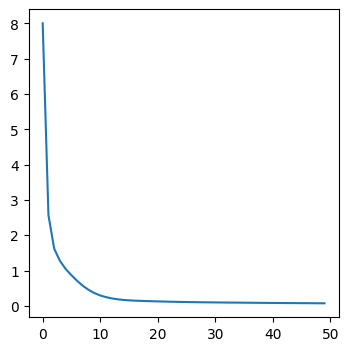

In [112]:
# After training the Sparse Autoencoder
# Save the model and optimizer state
torch.save({
    'autoencoder_state_dict': ae.state_dict(),
    'optimizer_state_dict': opt.state_dict(),
}, 'sparse_ae_model.pth')

In [ ]:
ckpt = torch.load("sparse_ae_model.pth", map_location=DEVICE)
ae.load_state_dict(ckpt["autoencoder_state_dict"])
opt.load_state_dict(ckpt["optimizer_state_dict"])
ae.eval()

In [80]:
len(scores)

768

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token_id = tokenizer.eos_token_id
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    load_in_8bit=False,
    torch_dtype=torch.float16,
    device_map="mps",
    output_hidden_states=True
)
model.eval()


/Users/thore/Library/Python/3.9/lib/python/site-packages/transformers/generation/configuration_utils.py:818: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_hidden_states` is. When `return_dict_in_generate` is not `True`, `output_hidden_states` is ignored.
  warnings.warn(
Loading checkpoint shards:  50%|█████     | 1/2 [00:10<00:10, 10.03s/it]

In [134]:

# positive for sql‐favoring neurons
signs = np.sign(scores[topn_neurons])
bias = torch.zeros(acts.size(1), device=DEVICE)
bias[topn_neurons] = 10 * torch.from_numpy(signs).to(DEVICE)

# hook on the final layernorm in the backbone, before lm_head
def add_bias(module, inp, out):
    # out: (B, L, H)
    tmp = bias.to(dtype=out.dtype, device=out.device)
    return out + tmp.unsqueeze(0).unsqueeze(0)


In [159]:
scores[topn_neurons]

array([3.2930229, 3.3195653, 3.321502 , 3.33833  , 3.3401217, 3.3517132,
       3.352246 , 3.3571422, 3.3832123, 3.3903913, 3.4079642, 3.414322 ,
       3.4254827, 3.428725 , 3.4324152, 3.4324868, 3.4345856, 3.4372764,
       3.451357 , 3.452242 , 3.4627178, 3.467228 , 3.4717083, 3.4724936,
       3.473466 , 3.5340996, 3.6043224, 3.6069748, 3.6085992, 3.610738 ,
       3.6199508, 3.6375463, 3.6660383, 3.6692495, 3.6763582, 3.6820667,
       3.695308 , 3.7264323, 3.7936544, 3.8077564, 3.9036002, 3.9217443,
       3.9259481, 3.9487538, 3.9929042, 4.021389 , 4.027663 , 4.0982656,
       4.1752095, 4.181133 ], dtype=float32)

In [135]:
# pick a dummy input
tok = tokenizer("SELECT", return_tensors="pt").to(DEVICE)
with torch.no_grad():
    out1 = model(**tok, output_hidden_states=True).hidden_states[-1]    # no hook
hook_handle = model.model.norm.register_forward_hook(add_bias)
with torch.no_grad():
    out2 = model(**tok, output_hidden_states=True).hidden_states[-1]    # with hook
hook_handle.remove()

# compare the top‐N neurons
diff = (out2 - out1)[..., topn_neurons].abs().mean()
print("avg abs change on boosted neurons:", diff.item())

avg abs change on boosted neurons: 10.0


In [127]:
for kw, ids in kw_token_ids.items():
  print(kw, "→", ids, tokenizer.convert_ids_to_tokens(ids))

SELECT → [4858] ['SELECT']
FROM → [30093] ['FROM']
WHERE → [26513] ['WHERE']
INSERT → [12698] ['INSERT']
UPDATE → [9239] ['UPDATE']
DELETE → [14424] ['DELETE']


In [130]:
out

tensor([[ 7812,   752,   279,  3565,   315,   279,  2701,  2311,   510,   785,
          5893,   315,   279, 74353, 63543,   323,   264, 12826,   198,   785,
          5893,   315,   279, 74353, 63543,   323,   264, 12826,    11,  1083,
          3881,   438,   576, 72598, 63543,    11]], device='mps:0')

In [157]:
topn_neurons

array([2009,  369, 1039, 1362,   12, 2010,  357,  450,  908, 1341, 1217,
        720,  361,   28, 1797, 1498,  951,  583,  161, 1987, 1418, 1927,
       1594,  340, 1973,  837,  198,  848,  305, 1979,  776,  274,  523,
        392, 1083, 1099, 1105, 1353,  972,  488,  294, 1921, 1119,  734,
       1623,  132, 1367, 1774, 1829, 1293])

In [201]:
# --- A) Build a big “SQL‐direction” vector in hidden‐space
#   We’ll boost not only our top-N neurons but also scale them.

hidden_size = acts.size(1)
mask = torch.zeros(hidden_size, device=DEVICE)
mask[topn_neurons] = 1.0

# You can tune these two scalars
ADD_ALPHA = 1.0    # additive boost
MUL_BETA  = 0.5    # multiplicative boost

# Precompute additive and multiplicative tensors
add_vec = ADD_ALPHA * mask
mul_vec = 1.0 + MUL_BETA * mask   # output = out * mul_vec + add_vec

# --- B) Define a hook that does both
def add_bias(module, inp, out):
    # out: (B, seq_len, hidden_size)
    # we first multiply, then add
    mv = mul_vec.view(1,1,-1).to(out)
    av = add_vec.view(1,1,-1).to(out)
    return out * mv + av

# now do your eval/generation…
# model.generate(…)
# Remember to remove all handles when done:


with-bias joint logp: 100%|██████████| 30/30 [00:13<00:00,  2.28it/s]


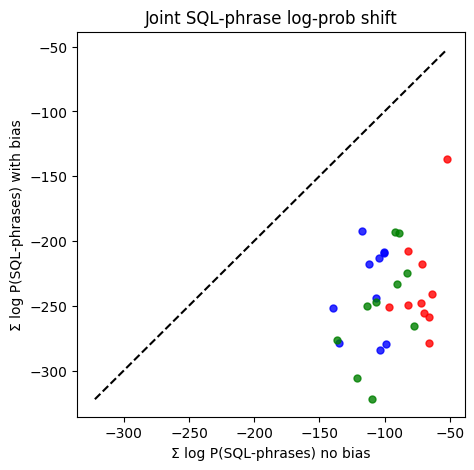

gen no-bias:   0%|          | 0/30 [00:00<?, ?it/s]/Users/thore/Library/Python/3.9/lib/python/site-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/Users/thore/Library/Python/3.9/lib/python/site-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/Users/thore/Library/Python/3.9/lib/python/site-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


SQL-detection rate no bias:  8/30 = 26.7%
         with bias:        0/30 = 0.0%


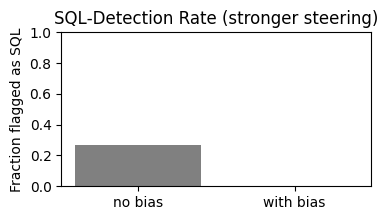


Example generations:
  no-bias → SELECT
    t1.id,
    t1.name,
    t2.name as category_name
FROM
    products AS t1
JOIN
    categories AS
  with-bias → SELECT anDeanVisionHealthGloom全同用大流差提用通下通通通下使下下下 yarg提使使使使使使

  no-bias → SELECT * FROM users WHERE id = 1;
SELECT * FROM users WHERE id = 2;
SELECT * FROM users WHERE id = 3;

SELECT * FROM users WHERE id
  with-bias → SELECT * FROM userscare1.github全同用大槙隼差差差差差差 yarg提使楧 Detay差差差差差差楫 Detay�

  no-bias → INSERT INTO orders (order_date, customer_id, total_price)
VALUES ('2023-01-01', 1, 150.00
  with-bias → INSERT INTO orders (K通任务用大同全同全通全通全通全通全通全通全通全通全通全通全通全通

  no-bias → UPDATE products SET  `name` = 'New Name', `price` = 100 WHERE id = 1;
UPDATE products SET  `name` = 'New
  with-bias → UPDATE products SET  anDeanGArmyGArmyMuggador1VisionAHealthAVisionFHealthVisionVisionVisionVisionVisionVisionVisionVisionVisionVisionVisionVision用全同

  no-bias → DELETE FROM customers WHERE  id = 1;
DELETE FROM orders WHERE customer_id = 1;
DELETE FR

In [6]:
import re
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

# ASSUMES: you’ve already computed
#   - acts            : (N, H) your extracted activations
#   - topn_neurons    : list/array of H indices you want to boost
#   - model, tokenizer
#   - DEVICE

# 1) BUILD ADDITIVE & MULTIPLICATIVE VECTORS
hidden_size = acts.size(1)
mask = torch.zeros(hidden_size, device=DEVICE)
mask[topn_neurons] = 1.0

ADD_ALPHA = 10.0    # additive boost magnitude
MUL_BETA  = 2   # multiplicative boost factor

add_vec = ADD_ALPHA * mask                # will be added
mul_vec = 1.0 + MUL_BETA * mask           # will be multiplicative

# 2) DEFINE A “SQL‐STEER” HOOK
def sql_steer_hook(module, inp, out):
    # out: (batch, seq_len, hidden_size)
    mv = mul_vec.view(1,1,-1).to(out)
    av = add_vec.view(1,1,-1).to(out)
    return out * mv + av

# 3) REGISTER ON MULTIPLE MODULES
handles = []
# final output norm
handles.append(model.model.norm.register_forward_hook(sql_steer_hook))
# last layer MLP down‐projection (just before residual add back)
last = model.model.layers[-1]
handles.append(last.mlp.down_proj.register_forward_hook(sql_steer_hook))
# last layer post‐attention norm
handles.append(last.post_attention_layernorm.register_forward_hook(sql_steer_hook))

# 4) PHRASE LOG-PROB FUNCTION
def phrase_logprob(prompt: str, cont: str):
    """
    Joint log P(cont | prompt), where cont is a short string,
    e.g. " FROM" or ";"
    """
    # tokenize prompt and continuation
    tok_p = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    cont_ids = tokenizer(cont, add_special_tokens=False).input_ids

    # forward on prompt
    with torch.no_grad():
        out = model(**tok_p)
        logits = out.logits  # (1, L, V)

    total_lp = 0.0
    prev_ids = tok_p.input_ids
    for tid in cont_ids:
        logp = torch.log_softmax(logits[0, -1], dim=-1)[tid].item()
        total_lp += logp
        # append that token and re-forward to get next
        prev_ids = torch.cat([prev_ids, torch.tensor([[tid]], device=DEVICE)], dim=1)
        with torch.no_grad():
            out = model(input_ids=prev_ids)
            logits = out.logits
    return total_lp

# 5) BUILD EVAL SET
sql_prompts = [
    "SELECT", "SELECT * FROM users", "INSERT INTO orders (",
    "UPDATE products SET ", "DELETE FROM customers WHERE ",
    "CREATE TABLE x (", "ALTER TABLE x ADD ", "GRANT SELECT ON",
    "DROP TABLE", "REVOKE INSERT ON"
]
nl_prompts = [
    "The capital of France is", "Explain quantum mechanics",
    "Once upon a time", "In a distant galaxy,", "The quick brown fox",
    "Summarize Hamlet", "How do you bake", "What is the weather",
    "Why is the sky", "Tell me a story"
]
ambig_prompts = [
    "List all items", "Count the number of", "What is the total",
    "Find the difference between", "Show me the details",
    "Provide all entries where", "Give me the names of",
    "Display the results", "Extract data from", "Make a list of"
]
eval_prompts = sql_prompts + nl_prompts + ambig_prompts
labels       = ["SQL"]*len(sql_prompts) + ["NL"]*len(nl_prompts) + ["AMBIG"]*len(ambig_prompts)

# 6) PHRASES TO TRACK
phrases = [" SELECT", " FROM", " WHERE", " INSERT", " UPDATE", ";"]

# 7) COMPUTE JOINT LOG-PROB SUM FOR EACH PROMPT
model.eval()
torch.manual_seed(0)

# ensure handles are active for "with bias" and removed for "no bias"
for h in handles: h.remove()
no_bias_scores = []
for p in tqdm(eval_prompts, desc="no-bias joint logp"):
    s = sum(phrase_logprob(p, ph) for ph in phrases)
    no_bias_scores.append(s)

for h in handles: h.remove()
with_bias_scores = []
for p in tqdm(eval_prompts, desc="with-bias joint logp"):
    # re-install hooks
    for h in handles: h.remove()
    handles[:] = [
        model.model.norm.register_forward_hook(sql_steer_hook),
        last.mlp.down_proj.register_forward_hook(sql_steer_hook),
        last.post_attention_layernorm.register_forward_hook(sql_steer_hook)
    ]
    s = sum(phrase_logprob(p, ph) for ph in phrases)
    with_bias_scores.append(s)
# finally remove hooks
for h in handles: h.remove()

# 8) PLOT JOINT LOG-PROB SHIFT
x = np.array(no_bias_scores)
y = np.array(with_bias_scores)
colors = {"SQL":"red","NL":"blue","AMBIG":"green"}

plt.figure(figsize=(5,5))
for xi, yi, lab in zip(x, y, labels):
    plt.scatter(xi, yi, c=colors[lab], s=25, alpha=0.8)
mn, mx = min(x.min(), y.min()), max(x.max(), y.max())
plt.plot([mn,mx],[mn,mx],"k--")
plt.xlabel("Σ log P(SQL‐phrases) no bias")
plt.ylabel("Σ log P(SQL‐phrases) with bias")
plt.title("Joint SQL‐phrase log-prob shift")
plt.show()

# 9) FULL‐SEQ GENERATION + SQL‐DETECTOR
sql_kw_set = {"SELECT","FROM","WHERE","INSERT","UPDATE","DELETE","TABLE","VALUES",";"}
def is_sql_gen(text: str):
    toks = re.findall(r"\b[A-Z]+\b|;", text.upper())
    kw_count = sum(1 for t in toks if t in sql_kw_set)
    return kw_count >= 2 and ";" in text

# generate without bias
for h in handles: h.remove()
gen_no = []
for p in tqdm(eval_prompts, desc="gen no-bias"):
    out = model.generate(**tokenizer(p, return_tensors="pt").to(DEVICE),
                         max_new_tokens=32, do_sample=False)
    gen_no.append(tokenizer.decode(out[0], skip_special_tokens=True))

# generate with bias
handles[:] = [
    model.model.norm.register_forward_hook(sql_steer_hook),
    last.mlp.down_proj.register_forward_hook(sql_steer_hook),
    last.post_attention_layernorm.register_forward_hook(sql_steer_hook)
]
gen_yes = []
for p in tqdm(eval_prompts, desc="gen with-bias"):
    out = model.generate(**tokenizer(p, return_tensors="pt").to(DEVICE),
                         max_new_tokens=32, do_sample=False)
    gen_yes.append(tokenizer.decode(out[0], skip_special_tokens=True))
for h in handles: h.remove()

det_no  = [is_sql_gen(t) for t in gen_no]
det_yes = [is_sql_gen(t) for t in gen_yes]

print(f"\nSQL-detection rate no bias:  {sum(det_no)}/{len(det_no)} = {100*sum(det_no)/len(det_no):.1f}%")
print(f"         with bias:        {sum(det_yes)}/{len(det_yes)} = {100*sum(det_yes)/len(det_yes):.1f}%")

plt.figure(figsize=(4,2))
plt.bar([0,1],[np.mean(det_no), np.mean(det_yes)],
        tick_label=["no bias","with bias"], color=["gray","orange"])
plt.ylim(0,1)
plt.ylabel("Fraction flagged as SQL")
plt.title("SQL‐Detection Rate (stronger steering)")
plt.show()

# 10) SHOW EXAMPLES
print("\nExample generations:")
for i,p in enumerate(eval_prompts[:10]):

    print("  no-bias →", gen_no[i])
    print("  with-bias →", gen_yes[i])
    print()

SQL phrase → token IDs → tokens
' SELECT' → [19094] → ['ĠSELECT']
' FROM' → [4295] → ['ĠFROM']
' WHERE' → [5288] → ['ĠWHERE']
' INSERT' → [39518] → ['ĠINSERT']
' UPDATE' → [22893] → ['ĠUPDATE']
' DELETE' → [17197] → ['ĠDELETE']
Avg abs hidden‐state shift on boosted neurons (first few prompts):
'SELECT' → 4.7383
'SELECT * FROM users' → 5.9922
'INSERT INTO orders (' → 5.2422
'UPDATE products SET ' → 6.0234
'DELETE FROM customers WHERE ' → 6.1680


with-bias phrase logp: 100%|██████████| 30/30 [00:02<00:00, 12.04it/s]


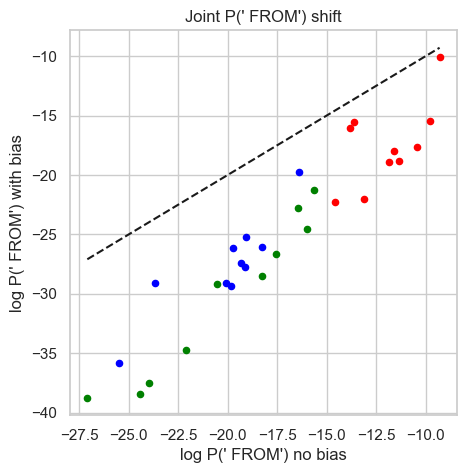

gen no-bias:   0%|          | 0/30 [00:00<?, ?it/s]/Users/thore/Library/Python/3.9/lib/python/site-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/Users/thore/Library/Python/3.9/lib/python/site-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/Users/thore/Library/Python/3.9/lib/python/site-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


Detection rate no bias:  4/30 = 13.3%
   with bias:            0/30 = 0.0%



/Users/thore/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8208 (\N{HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


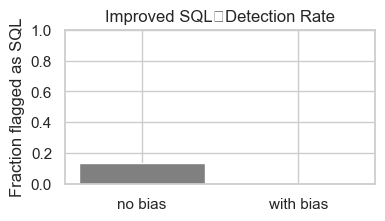


Examples:

[SQL] Prompt: 'SELECT'
 No‐bias → SELECT
CASE
	WHEN (SUM(CASE WHEN T.month = 'Jan' THEN 1 ELSE 0 END) + SUM(CASE WHEN T.month =
 With‐bias → SELECT  t.id as "transactionId",
        (select  (select  (select  (select  (select  (select  (select  (select

[SQL] Prompt: 'SELECT * FROM users'
 No‐bias → SELECT * FROM users WHERE 1=1 AND (email = 'email@email.com' OR (email LIKE 'email%' AND (email LIKE '%email.com')) OR (email
 With‐bias → SELECT * FROM users WHERE  (id = 1 or  2 or  3 or  4 or  5 or  6 or  7 or

[SQL] Prompt: 'INSERT INTO orders ('
 No‐bias → INSERT INTO orders (user_id, product_id)
VALUES (10001, 10001),
       (10002, 10
 With‐bias → INSERT INTO orders (user_id,address_id,status_id,date_of_order,date_of_delivery,date_of_receipt,date_of_payment,date_of_completion,date_of_returned_at,user_note,is_paid,is_return

[SQL] Prompt: 'UPDATE products SET '
 No‐bias → UPDATE products SET  `price`=10000,  `stock`=20000,  `status`=1 WHERE  `id`=154
 With‐bias → UPDATE pr

In [186]:
import re
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

DEVICE = "mps"
tokenizer = tokenizer  # from above
model     = model      # from above
hook_handle = hook_handle  # your existing handle
bias        = bias     # your existing bias vector
topn_neurons = topn_neurons  # your selected neuron indices

# 1) VERIFY THE KEYWORD TOKEN IDS
keywords = [" SELECT", " FROM", " WHERE", " INSERT", " UPDATE", " DELETE"]
kw_ids = {kw: tokenizer(kw, add_special_tokens=False).input_ids for kw in keywords}
print("SQL phrase → token IDs → tokens")
for kw, ids in kw_ids.items():
    print(f"{kw!r} → {ids} → {tokenizer.convert_ids_to_tokens(ids)}")

# 2) FUNCTION TO COMPUTE JOINT PROBABILITY OF A SHORT PHRASE continuation
def phrase_logprob(prompt: str, cont: str):
    # returns log P(cont | prompt)
    # cont is typically 2–3 tokens, e.g. " FROM"
    tok_p = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    tok_c = tokenizer(cont,   add_special_tokens=False).input_ids
    # first forward on prompt
    with torch.no_grad():
        out = model(**tok_p)
        logits = out.logits  # (1, L, V)
    logp = 0.0
    prev_ids = tok_p.input_ids
    for idx, token_id in enumerate(tok_c):
        # probability of tok_c[idx] given previous sequence
        lp = torch.log_softmax(logits[0, -1], dim=-1)[token_id].item()
        logp += lp
        # now feed that token back in to get next logits
        prev_ids = torch.cat([prev_ids, torch.tensor([[token_id]], device=DEVICE)], dim=1)
        with torch.no_grad():
            out = model(input_ids=prev_ids)
            logits = out.logits
    return logp

# 3) BUILD A LARGER EVAL SET
sql_prompts = [
    "SELECT", "SELECT * FROM users", "INSERT INTO orders (", "UPDATE products SET ",
    "DELETE FROM customers WHERE ", "CREATE TABLE x (", "ALTER TABLE x ADD ", 
    "GRANT SELECT ON", "REVOKE INSERT ON", "DROP TABLE"
]
nl_prompts = [
    "The capital of France is", "Explain quantum mechanics", "Once upon a time",
    "In a distant galaxy,", "The quick brown fox", "Summarize Hamlet", 
    "How do you bake", "What is the weather", "Why is the sky", "Tell me a story"
]
ambig_prompts = [
    "List all items", "Count the number of", "What is the total", 
    "Find the difference between", "Show me the details", "Make a list of", 
    "Provide all entries where", "Give me the names of", "Display the results",
    "Extract data from"
]
eval_prompts = sql_prompts + nl_prompts + ambig_prompts
labels       = ["SQL"]*len(sql_prompts) + ["NL"]*len(nl_prompts) + ["AMBIG"]*len(ambig_prompts)

# 4) VERIFY THE HOOK IS ACTUALLY SHIFTING THOSE NEURONS
def avg_neuron_shift(prompt: str):
    tok = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out_no = model(**tok, output_hidden_states=True).hidden_states[-1]
    h_pre = out_no[:, -1, topn_neurons]
    # install hook
    hdl = model.model.norm.register_forward_hook(add_bias)
    with torch.no_grad():
        out_yes = model(**tok, output_hidden_states=True).hidden_states[-1]
    h_post = out_yes[:, -1, topn_neurons]
    hdl.remove()
    return (h_post - h_pre).abs().mean().item()

print("Avg abs hidden‐state shift on boosted neurons (first few prompts):")
for p in eval_prompts[:5]:
    print(f"{p!r} → {avg_neuron_shift(p):.4f}")

# 5) MEASURE JOINT LOGPROB OF " FROM" NEXT
model.eval()
torch.manual_seed(0)

lp_nobias = []
lp_withbias = []

hook_handle.remove()
for p in tqdm(eval_prompts, desc="no-bias phrase logp"):
    lp_nobias.append(phrase_logprob(p, " FROM"))

hook_handle = model.model.norm.register_forward_hook(add_bias)
for p in tqdm(eval_prompts, desc="with-bias phrase logp"):
    lp_withbias.append(phrase_logprob(p, " FROM"))
hook_handle.remove()

# 6) PLOT JOINT‐LOGP SHIFT
x = np.array(lp_nobias)
y = np.array(lp_withbias)
colors = {"SQL":"red","NL":"blue","AMBIG":"green"}
plt.figure(figsize=(5,5))
for xi, yi, lab in zip(x,y,labels):
    plt.scatter(xi, yi, c=colors[lab], s=20)
plt.plot([x.min(), x.max()],[x.min(), x.max()],"k--")
plt.xlabel("log P(' FROM') no bias")
plt.ylabel("log P(' FROM') with bias")
plt.title("Joint P(' FROM') shift")
plt.show()

# 7) FULL‐SEQUENCE GENERATION + RICHER SQL‐DETECTOR
sql_kw_set = {"SELECT","FROM","WHERE","INSERT","UPDATE","DELETE","TABLE","VALUES",";"}
def is_sql_gen(text: str):
    toks = re.findall(r"\b[A-Z]+\b|;", text.upper())
    # require ≥2 SQL keywords AND at least one semicolon
    kw_count = sum(1 for t in toks if t in sql_kw_set)
    return kw_count>=2 and ";" in text

gen_nobias = []
gen_withbias = []

hook_handle and hook_handle.remove()
for p in tqdm(eval_prompts, desc="gen no-bias"):
    out = model.generate(**tokenizer(p, return_tensors="pt").to(DEVICE),
                         max_new_tokens=32, do_sample=False)
    gen_nobias.append(tokenizer.decode(out[0], skip_special_tokens=True))

hook_handle = model.model.norm.register_forward_hook(add_bias)
for p in tqdm(eval_prompts, desc="gen with-bias"):
    out = model.generate(**tokenizer(p, return_tensors="pt").to(DEVICE),
                         max_new_tokens=32, do_sample=False)
    gen_withbias.append(tokenizer.decode(out[0], skip_special_tokens=True))
hook_handle.remove()

det_nobias = [is_sql_gen(t) for t in gen_nobias]
det_withbias = [is_sql_gen(t) for t in gen_withbias]

print(f"\nDetection rate no bias:  {sum(det_nobias)}/{len(det_nobias)} = {100*sum(det_nobias)/len(det_nobias):.1f}%")
print(f"   with bias:            {sum(det_withbias)}/{len(det_withbias)} = {100*sum(det_withbias)/len(det_withbias):.1f}%")

plt.figure(figsize=(4,2))
plt.bar([0,1],[np.mean(det_nobias), np.mean(det_withbias)],
        tick_label=["no bias","with bias"], color=["gray","orange"])
plt.ylim(0,1)
plt.ylabel("Fraction flagged as SQL")
plt.title("Improved SQL‐Detection Rate")
plt.show()

# 8) SHOW A FEW EXAMPLES
print("\nExamples:")
for i,p in enumerate(eval_prompts[:10]):
    print(f"\n[{labels[i]}] Prompt: {p!r}")
    print(" No‐bias →", gen_nobias[i])
    print(" With‐bias →", gen_withbias[i])

In [153]:
gen_withbias

['SELECT\nCASE\nWHEN  (id_patient_patient.id_patient_patient_patient_patient_patient_patient_patient_patient_patient_patient_patient_patient_patient_patient_patient_patient_patient_patient_patient_patient_patient',
 'SELECT * FROM users WHERE  (id_user = 1 or  2 or  3 or  4 or  5 or  6 or  7',
 'INSERT INTO orders (id_customer,id_product_price,id_delivery_price,id_order_status_price,id_payment_price,id_delivery_price_price,id_delivery_price_price_price,id_delivery_price_price_price_price)\nVALUES',
 'UPDATE products SET  "pricePerUnitPriceMonthlyIncomeMonthlyIncomeMonthlyIncomeMonthlyIncomeMonthlyIncomeMonthlyIncomeMonthlyIncomeMonthlyIncomeMonthlyIncomeMonthlyIncomeMonthlyIncomeMonthlyIncomeMonthlyIncomeMonthly',
 'DELETE FROM customers WHERE  "customerid〝 = \'customerid〝";\nDelete the "customerid〝" in the "customers〝 table.\nDeleting a "customerid" in a',
 'CREATE TABLE x (id int, a text, b text, c text, d text, e text, f text, g text, h text, i text, j text',
 'ALTER TABLE x ADD  (i

In [151]:
gen_nobias

['SELECT\nCASE\nWHEN  (  1000000000000000000000 Özel',
 "SELECT * FROM users WHERE 1=1\nAND (id = 'user_id')\nAND (email = 'user_email')\nAND (password = 'user_password')\nAND (",
 'INSERT INTO orders (customer_id, product_id)\nVALUES (10001, 10001),\n       (100 İs there a way to do',
 'UPDATE products SET  "pricePerUnitInStock" =  1000000000000000000000',
 "DELETE FROM customers WHERE 1=1\nUPDATE  customers SET  first_name = 'John'  ,  last_name = 'Smith'\nWHERE  1=1\nINSERT",
 'CREATE TABLE x (id int, a text, b text, c text, d text, e text, f text, g text, h text, i text, j text',
 'ALTER TABLE x ADD  (id_sala int, id_pista int, id_jogador int, id_time int,  id_partida int,  id_jogo int',
 'GRANT SELECT ON public.users_to_tasks_task_id_user_id_to_tasks_task_id_user_id_gist TO "user";\nGRANT SELECT ON public.users_to_tasks_task_id_user_id',
 'REVOKE INSERT ON "public"."users" FROM "user_admin";\nGRANT INSERT ON "public"."users" TO "user_admin";\n\nREVOKE SELECT, UPDATE, DELETE ON',
 

In [152]:
model

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 2048)
    (layers): ModuleList(
      (0-35): 36 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=True)
          (k_proj): Linear(in_features=2048, out_features=256, bias=True)
          (v_proj): Linear(in_features=2048, out_features=256, bias=True)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=2048, out_features=11008, bias=False)
          (up_proj): Linear(in_features=2048, out_features=11008, bias=False)
          (down_proj): Linear(in_features=11008, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((2048,), eps=1e-06)
    (rotary_emb):

In [188]:
lp_withbias

[-15.4765625,
 -10.03125,
 -16.0625,
 -18.890625,
 -22.234375,
 -15.5078125,
 -18.015625,
 -17.65625,
 -22.0,
 -18.828125,
 -27.375,
 -27.78125,
 -29.078125,
 -35.8125,
 -19.765625,
 -26.03125,
 -29.375,
 -26.140625,
 -29.0625,
 -25.25,
 -24.5625,
 -37.5,
 -29.1875,
 -38.75,
 -22.75,
 -38.46875,
 -28.53125,
 -34.75,
 -21.265625,
 -26.6875]

In [189]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df2 = pd.DataFrame({
    "no_bias":   lp_nobias,
    "with_bias": lp_withbias,
    "label":     labels
})


/var/folders/7w/mkd8r9995nzdpp6zj2smrw580000gn/T/ipykernel_5879/1750633477.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Prompt Type")


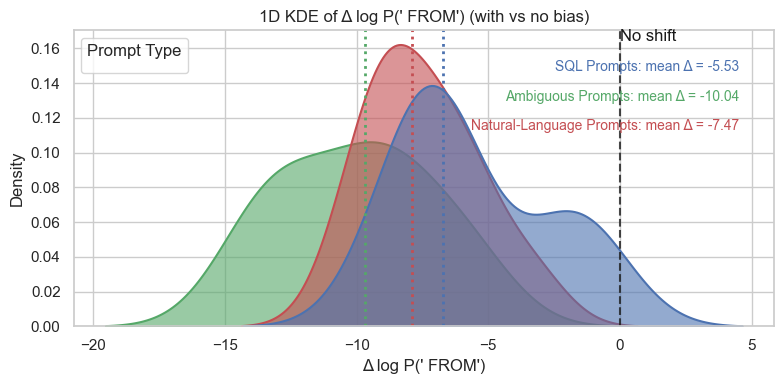

In [190]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# assume df2 has columns: no_bias, with_bias, label
# and label values in {"SQL","AMBIG","NL"}
df2["delta"] = df2.with_bias - df2.no_bias

# human-friendly label map
readable = {
    "SQL":   "SQL Prompts",
    "AMBIG": "Ambiguous Prompts",
    "NL":    "Natural-Language Prompts"
}
df2["label_friendly"] = df2.label.map(readable)

# compute medians and means
grouped = df2.groupby("label_friendly").delta
medians = grouped.median()
means   = grouped.mean()

# set up colors
palette = {
    "SQL Prompts": "C0",
    "Ambiguous Prompts": "C2",
    "Natural-Language Prompts": "C3"
}

plt.figure(figsize=(8,4))
sns.set_style("whitegrid")

# your existing KDE plot
sns.kdeplot(
    data=df2,
    x="delta",
    hue="label_friendly",
    fill=True,
    common_norm=False,
    palette=palette,
    alpha=0.6,
    linewidth=1.5
)
plt.axvline(0, ls="--", c="k", alpha=0.8)
plt.text(0, plt.ylim()[1]*0.98, "No shift", ha="left", va="center", color="k")

# annotate median lines
for lbl, med in medians.items():
    plt.axvline(med, color=palette[lbl], ls=":", lw=2)


# draw a semi‐transparent rectangle as shared background
ax = plt.gca()
# now write each line in its own color
y0 = 0.90
dy = -0.10
for i, lbl in enumerate(palette.keys()):
    txt = f"{lbl}: mean Δ = {means[lbl]:+.2f}"
    ax.text(
        0.95,          # x in axis‐fraction coords (right‐aligned)
        y0 + i*dy,     # y coords stepping down
        txt,
        transform=ax.transAxes,
        ha="right", va="top",
        color=palette[lbl],
        fontsize=10
    )

plt.title("1D KDE of Δ log P(' FROM') (with vs no bias)")
plt.xlabel("Δ log P(' FROM')")
plt.ylabel("Density")
plt.legend(title="Prompt Type")
plt.tight_layout()
plt.show()

/var/folders/7w/mkd8r9995nzdpp6zj2smrw580000gn/T/ipykernel_5879/1718697141.py:98: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Prompt Type", fontsize=10, title_fontsize=11)


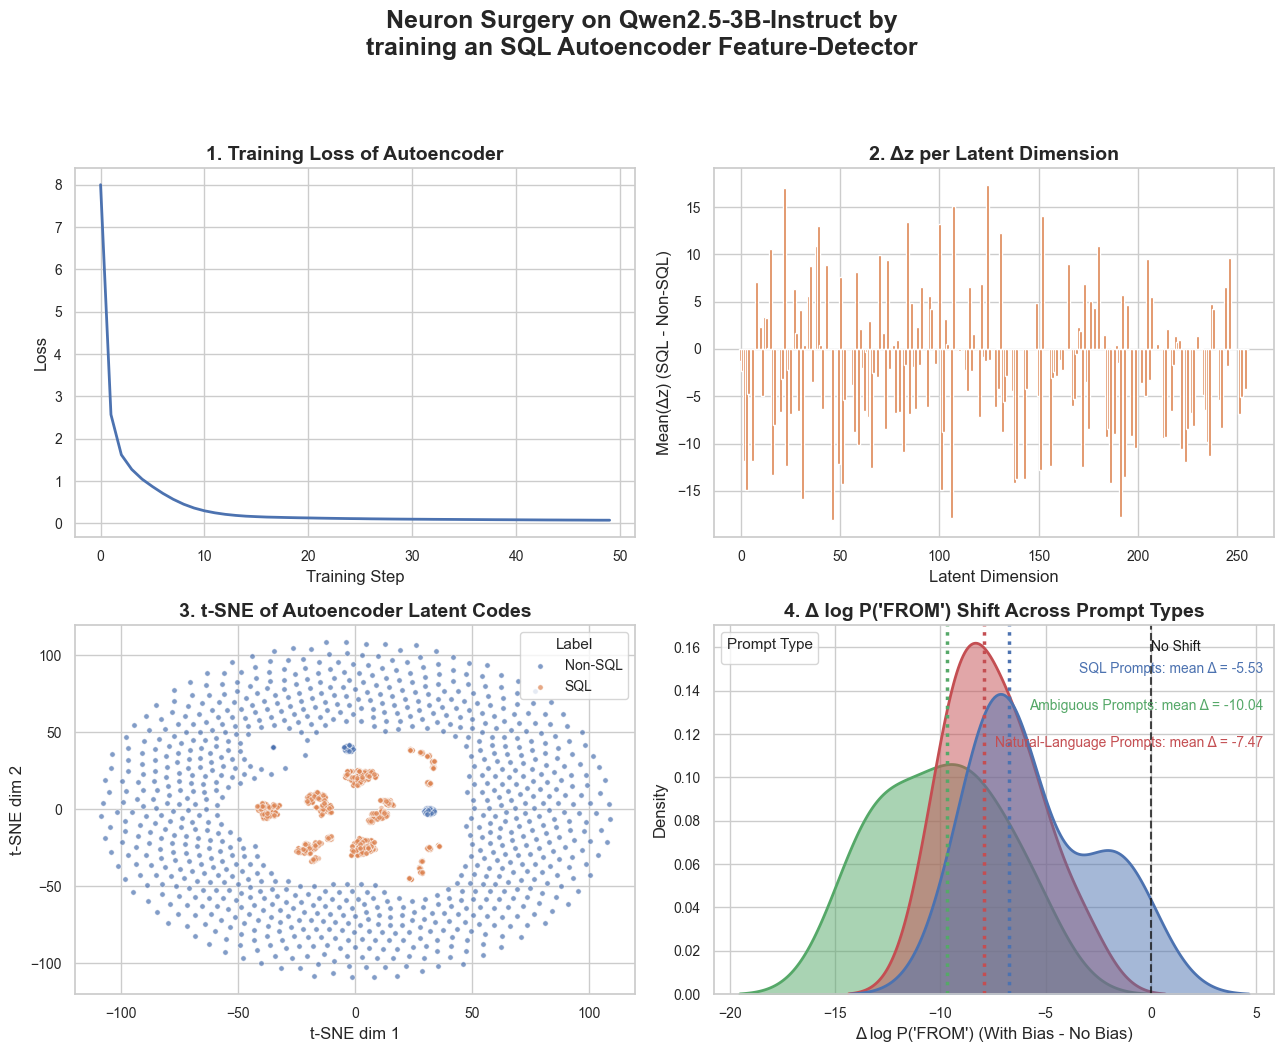

In [198]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE

# Assume you have: losses_log, dz, Z, labs, df2 already defined

# Preprocess df2
df2["delta"] = df2.with_bias - df2.no_bias
readable = {"SQL": "SQL Prompts", "AMBIG": "Ambiguous Prompts", "NL": "Natural-Language Prompts"}
df2["label_friendly"] = df2.label.map(readable)

# Group statistics
grouped = df2.groupby("label_friendly").delta
medians = grouped.median()
means = grouped.mean()

palette = {
    "SQL Prompts": "C0",
    "Ambiguous Prompts": "C2",
    "Natural-Language Prompts": "C3"
}

# Begin figure
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
plt.subplots_adjust(hspace=0.35, wspace=0.3)

# --- Subplot 1: Loss curve ---
ax = axes[0, 0]
ax.plot(losses_log, color="C0", linewidth=2)
ax.set_title("1. Training Loss of Autoencoder", fontsize=14, fontweight="bold")
ax.set_xlabel("Training Step", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.tick_params(labelsize=10)

# --- Subplot 2: Δz per latent dim ---
ax = axes[0, 1]
ax.bar(np.arange(len(dz)), dz, color="C1", width=1.5)
ax.set_title("2. Δz per Latent Dimension", fontsize=14, fontweight="bold")
ax.set_xlabel("Latent Dimension", fontsize=12)
ax.set_ylabel("Mean(Δz) (SQL - Non-SQL)", fontsize=12)
ax.tick_params(labelsize=10)

# --- Subplot 3: t-SNE ---
tsne = TSNE(n_components=2, init="random", random_state=0)
Z2 = tsne.fit_transform(Z)

ax = axes[1, 0]
ax.scatter(Z2[labs==0,0], Z2[labs==0,1], s=15, label="Non-SQL", alpha=0.7, edgecolors='w', linewidths=0.5)
ax.scatter(Z2[labs==1,0], Z2[labs==1,1], s=15, label="SQL", alpha=0.7, edgecolors='w', linewidths=0.5)
ax.legend(title="Label", fontsize=10, title_fontsize=11)
ax.set_title("3. t-SNE of Autoencoder Latent Codes", fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE dim 1", fontsize=12)
ax.set_ylabel("t-SNE dim 2", fontsize=12)
ax.tick_params(labelsize=10)

# --- Subplot 4: KDE of Δ log P('FROM') ---
ax = axes[1, 1]
sns.kdeplot(
    data=df2,
    x="delta",
    hue="label_friendly",
    fill=True,
    common_norm=False,
    palette=palette,
    alpha=0.5,
    linewidth=2,
    ax=ax
)

ax.axvline(0, ls="--", c="k", alpha=0.8, linewidth=1.5)
ax.text(0, ax.get_ylim()[1]*0.96, "No Shift", ha="left", va="top", color="k", fontsize=10)

for lbl, med in medians.items():
    ax.axvline(med, color=palette[lbl], ls=":", lw=2.5)

# Add mean delta text
y0 = 0.9
dy = -0.1
for i, lbl in enumerate(palette.keys()):
    txt = f"{lbl}: mean Δ = {means[lbl]:+.2f}"
    ax.text(
        0.98,
        y0 + i*dy,
        txt,
        transform=ax.transAxes,
        ha="right",
        va="top",
        color=palette[lbl],
        fontsize=10
    )

ax.set_title("4. Δ log P('FROM') Shift Across Prompt Types", fontsize=14, fontweight="bold")
ax.set_xlabel("Δ log P('FROM') (With Bias - No Bias)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.legend(title="Prompt Type", fontsize=10, title_fontsize=11)
ax.tick_params(labelsize=10)

# Global Title
fig.suptitle("Neuron Surgery on Qwen2.5-3B-Instruct by\ntraining an SQL Autoencoder Feature-Detector", fontsize=18, fontweight="bold", y=1.05)

plt.tight_layout()
plt.show()
